In [67]:
import re
import time
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats

In [68]:
#set plot formatting to seaborn's default
sns.set() 

In [69]:
%matplotlib inline

# Loading the cleaned NBA dataset from Step 1 - Wrangling

In [70]:
df = pd.read_csv('../Data/nba-1-data-wrangling.csv')
df.head().T

,0,1,2,3,4
player,Luka Dončić,Shai Gilgeous-Alexander,Jaylen Brown,Kevin Durant,Tyrese Maxey
team,LAL,OKC,BOS,HOU,PHI
gp,64,68,71,78,70
min,2289,2259,2443,2840,2661
fgm,693,731,736,716,694
fga,1457,1321,1543,1376,1501
fg_pct,0.476,0.553,0.477,0.52,0.462
fg3m,254,115,140,186,220
fg3a,694,298,404,450,599
fg3_pct,0.366,0.386,0.347,0.413,0.367


In [71]:
df.shape

(582, 33)

# Highest Salaries

In [72]:
df[['player', 'team', 'salary']].sort_values(by='salary', ascending=False).head(10)

,player,team,salary
57,Stephen Curry,GSW,59606817.0
9,Nikola Jokić,DEN,55224526.0
78,Joel Embiid,PHI,55224526.0
3,Kevin Durant,HOU,54708609.0
83,Giannis Antetokounmpo,MIL,54126450.0
145,Jimmy Butler III,GSW,54126450.0
298,Jayson Tatum,BOS,54126450.0
270,Anthony Davis,WAS,54126450.0
22,Karl-Anthony Towns,NYK,53142264.0
2,Jaylen Brown,BOS,53142264.0


# Highest Scorers

In [73]:
df[['player', 'team', 'pts']].sort_values(by='pts', ascending=False).head(10)

,player,team,pts
0,Luka Dončić,LAL,2143
1,Shai Gilgeous-Alexander,OKC,2117
2,Jaylen Brown,BOS,2038
3,Kevin Durant,HOU,2026
4,Tyrese Maxey,PHI,1980
5,Donovan Mitchell,CLE,1952
6,Jalen Brunson,NYK,1927
7,Jamal Murray,DEN,1905
8,Kawhi Leonard,LAC,1813
9,Nikola Jokić,DEN,1799


# Empirical Cumulative Distribution Function (ECDF)
### FGA (Field Goals Attempted): This curve rises steeply at the beginning. Around 40% of players have less than 200 field goals attempted. Shots are likely concentrated in the hands of stars and starting 5 players.
### FG3A (3-pointers Attempted): Vertial jump at 0 which indicates that some players never shoot a 3-pointer. These are likely centers or defensive-oriented players.
### FT_PCT (Free Throw Percentage): The curve rises sharply between 70 and 90% (a majority of players are shooting decently from the free throw line). Above 90% appears to be an elite status. 

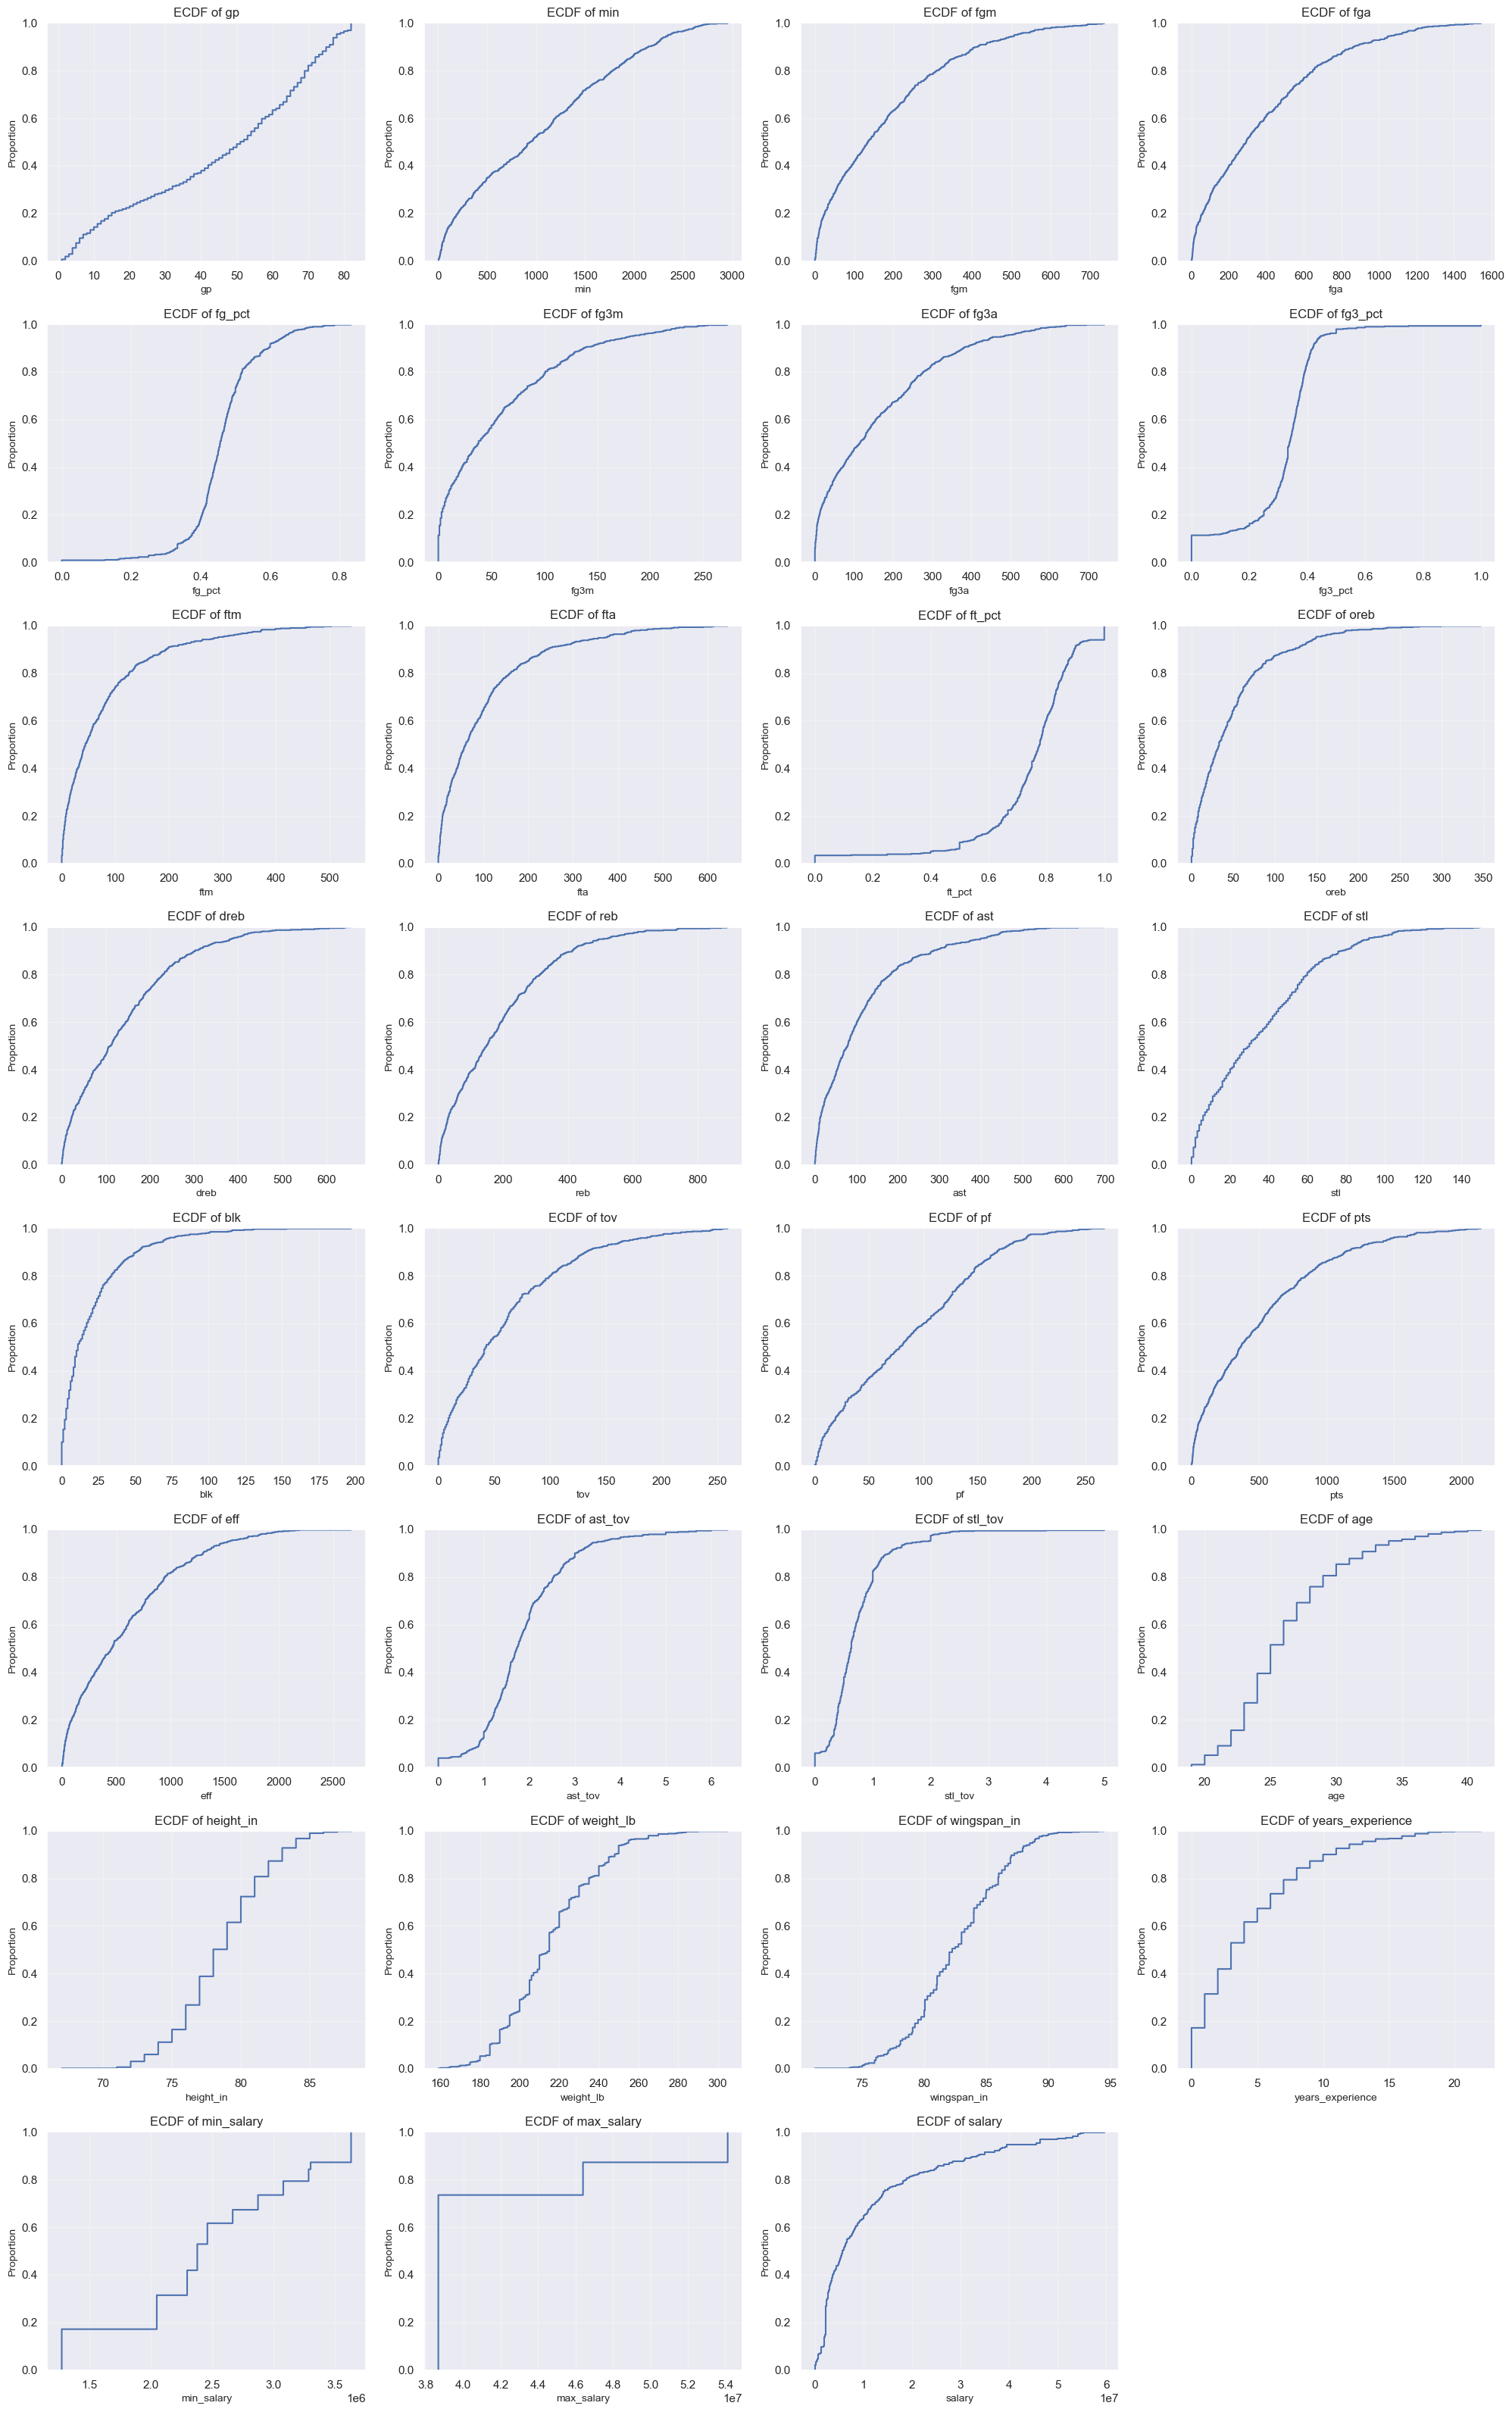

In [74]:
# 1. Automatically select all numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# 2. Set up a grid with 4 columns and N rows
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create the figure grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() # Flatten to 1D array for easy iteration

# 3. Loop through columns and plot the ECDF
for i, col in enumerate(numerical_cols):
    sns.ecdfplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'ECDF of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Proportion', fontsize=10)
    axes[i].grid(True, alpha=0.3)

# 4. Remove any empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Scatterplots of Salary
### FGM, FGA, FTA, FTM, PTS: Have the higest R-squared values. These stand out compared to defensive stats like Rebounds, Blocks, and Steals. Players are mainly valued for their offensive ability over their defensive ability. 
### FG_PCT and FG3_PCT: Have no clear linear relationship with Salary. The low-salary players may have good percentages on low volume.

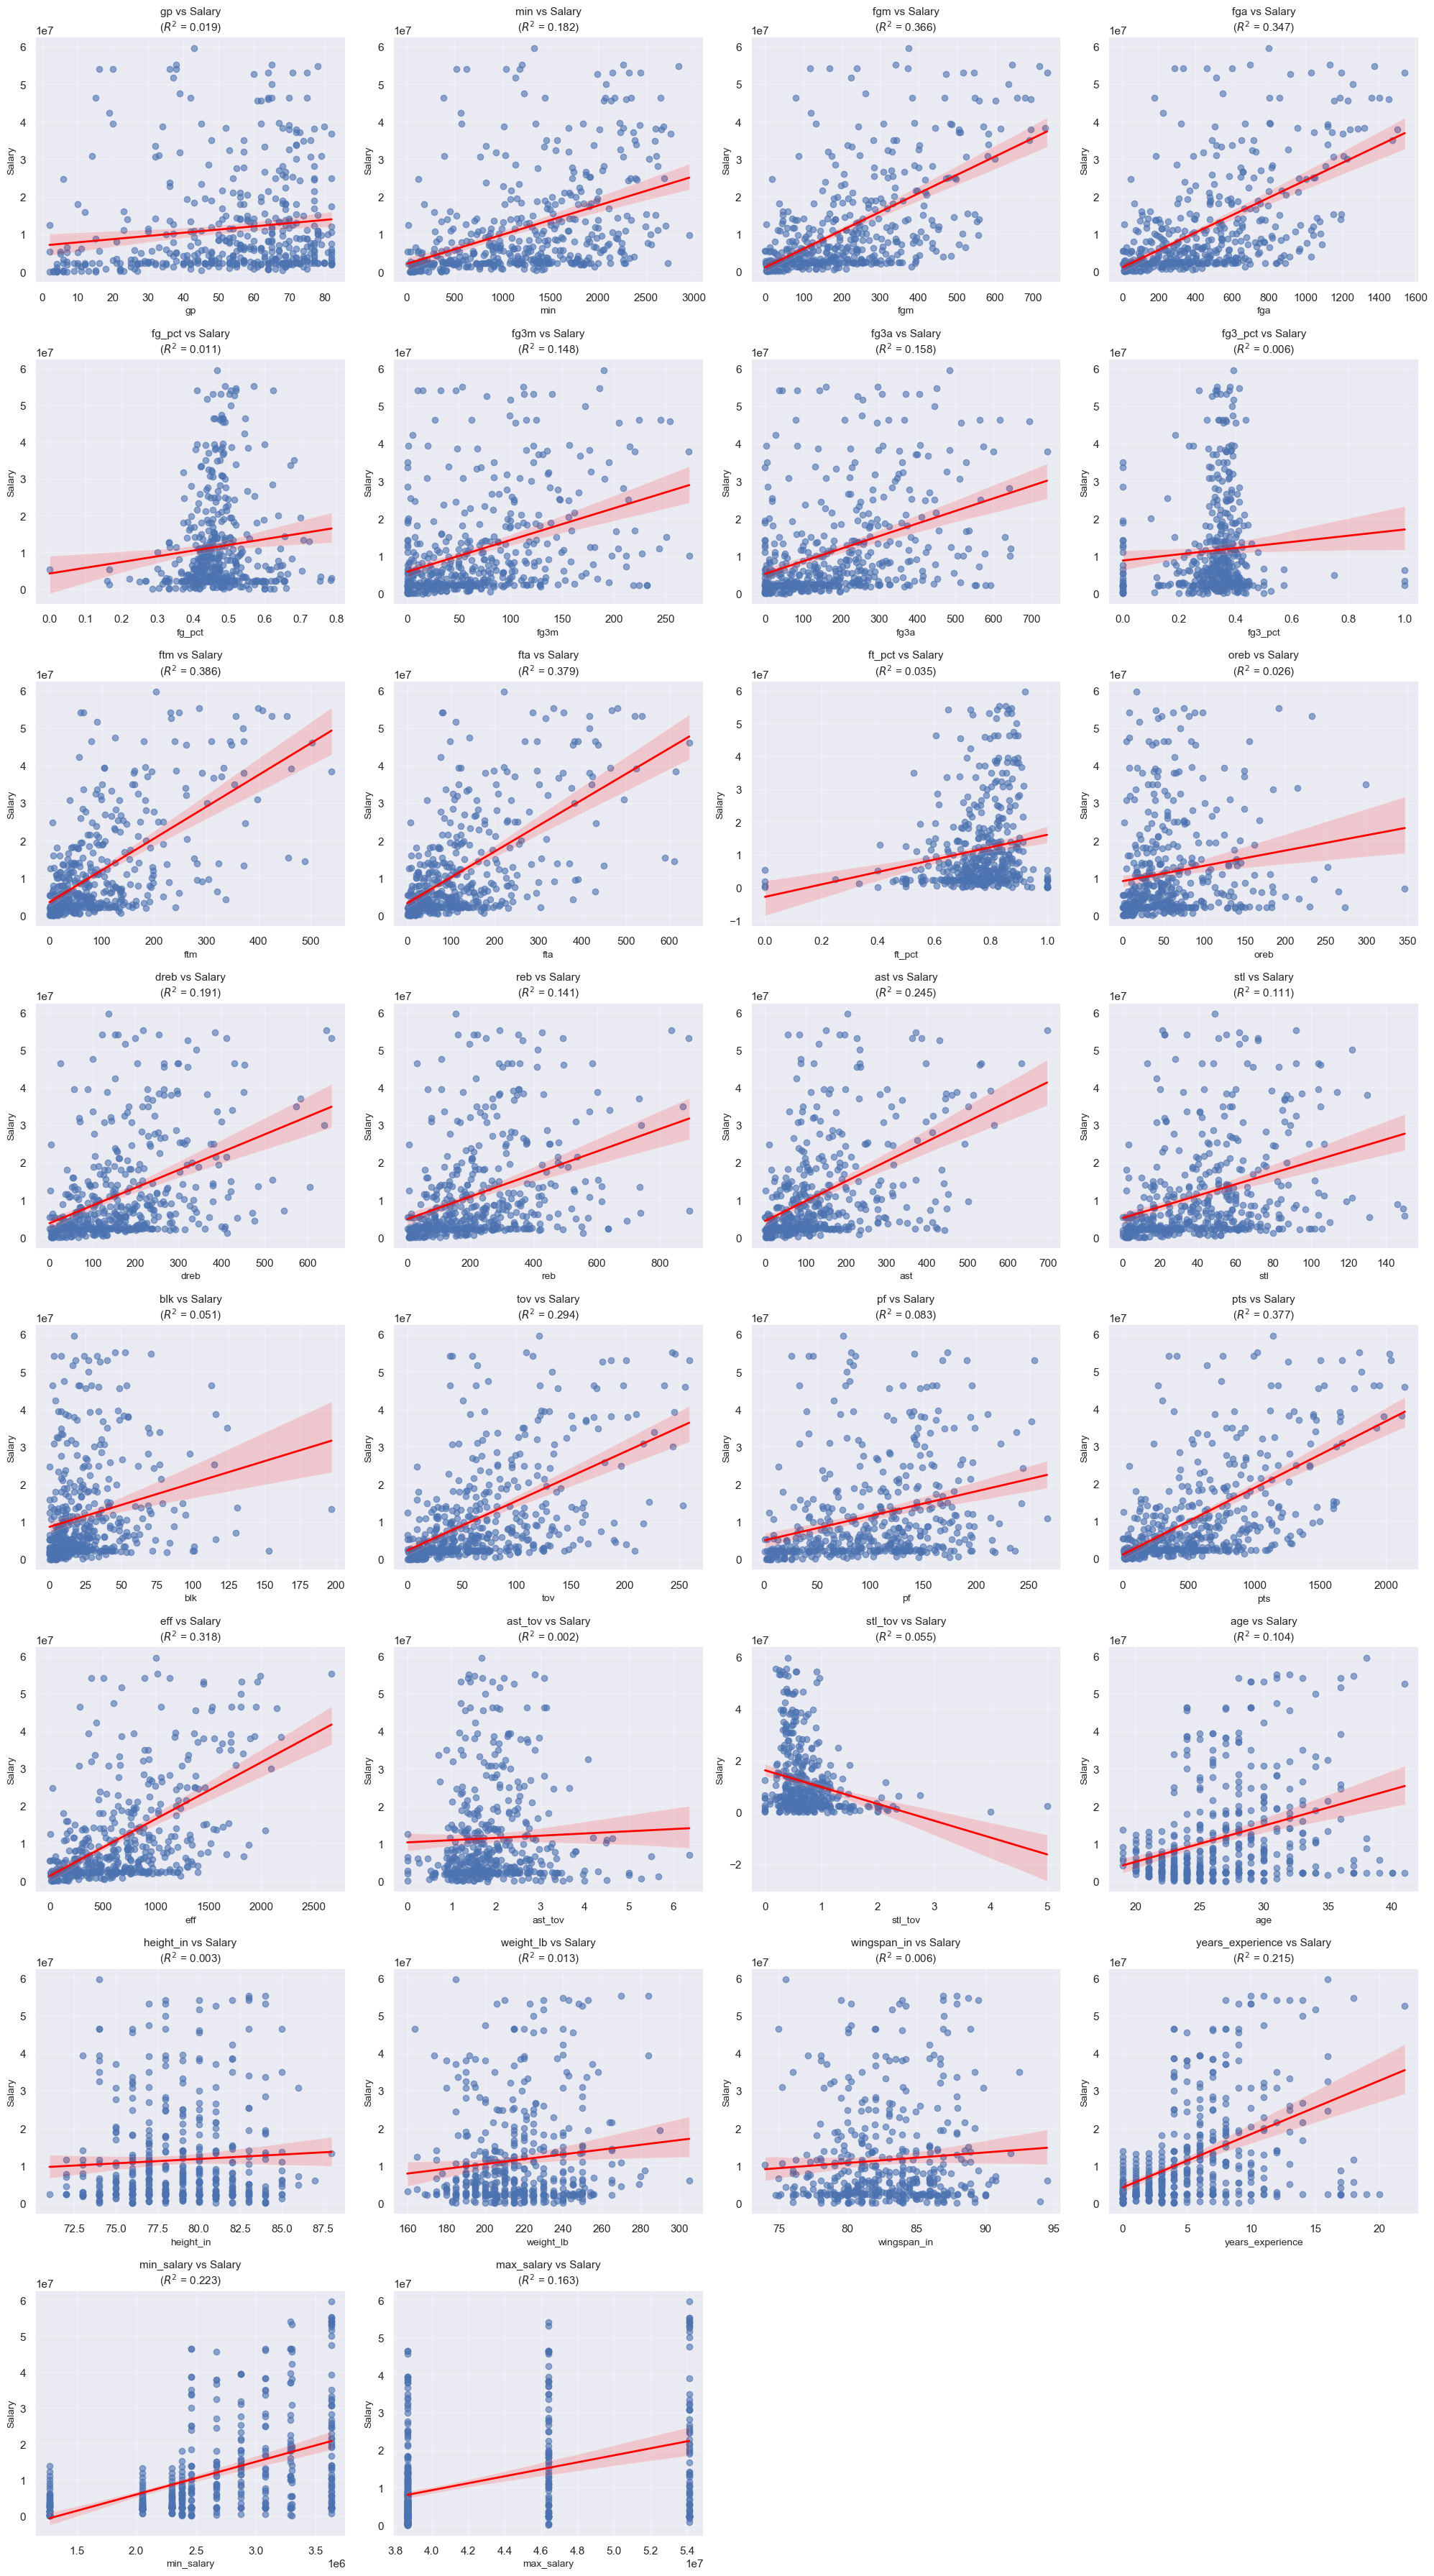

In [75]:
# 1. Get all numerical columns except 'salary'
numerical_cols = df.select_dtypes(include=['number']).columns
features = [col for col in numerical_cols if col != 'salary']

# 2. Set up a grid with 4 columns and N rows
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

# Create the figure grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array for easy iteration

# 3. Loop through features and create regression plots vs Salary
for i, col in enumerate(features):
    # Drop NaNs for this specific pair to avoid stats errors if any exist
    clean_data = df[[col, 'salary']].dropna()
    
    if len(clean_data) > 1:
        # Calculate R-squared
        slope, intercept, r_value, p_value, std_err = stats.linregress(clean_data[col], clean_data['salary'])
        r_squared = r_value ** 2
        
        # Plot the scatter points and the red regression line
        sns.regplot(
            data=clean_data, 
            x=col, 
            y='salary', 
            ax=axes[i], 
            scatter_kws={'alpha': 0.6}, 
            line_kws={'color': 'red', 'linewidth': 2}
        )
        
        # Update title to include R-squared value
        axes[i].set_title(f'{col} vs Salary\n($R^2$ = {r_squared:.3f})', fontsize=11)
    else:
        # Fallback if there isn't enough data
        sns.scatterplot(data=df, x=col, y='salary', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'{col} vs Salary', fontsize=11)
        
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Salary', fontsize=10)
    axes[i].grid(True, alpha=0.3)

# 4. Remove any empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Salary > Max Salary
## 25%, 30%, 35% are the standard maxes, but some players hit performance criteria that pushes them higher (All-NBA selections, DPOY, MVP)

In [76]:
salary_check = df[df['salary'] > df['max_salary']]

In [77]:
salary_check

,player,team,gp,min,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,...,ast_tov,stl_tov,age,height_in,weight_lb,wingspan_in,years_experience,min_salary,max_salary,salary
2,Jaylen Brown,BOS,71,2443,736,1543,0.477,140,404,0.347,...,1.41,0.28,29.0,78,223.0,83.750000,9,3303774,46394100,53142264.0
3,Kevin Durant,HOU,78,2840,716,1376,0.520,186,450,0.413,...,1.51,0.25,37.0,83,240.0,88.750000,18,3634153,54126450,54708609.0
9,Nikola Jokić,DEN,65,2265,644,1132,0.569,112,295,0.380,...,2.87,0.38,31.0,83,284.0,86.940281,10,3634153,54126450,55224526.0
10,Anthony Edwards,MIN,61,2137,602,1231,0.489,205,514,0.399,...,1.30,0.48,24.0,76,225.0,80.051500,5,2667944,38661750,45550512.0
21,Cade Cunningham,DET,64,2172,548,1189,0.461,125,366,0.342,...,2.69,0.39,24.0,78,220.0,82.019723,4,2461463,38661750,46394100.0
39,Zion Williamson,NOP,62,1841,484,807,0.600,1,4,0.250,...,1.58,0.48,25.0,78,284.0,82.019723,6,2874436,38661750,39446090.0
53,Evan Mobley,CLE,65,2074,469,859,0.546,62,209,0.297,...,1.92,0.39,24.0,83,215.0,86.940281,4,2461463,38661750,46394100.0
57,Stephen Curry,GSW,43,1329,374,799,0.468,190,484,0.393,...,1.68,0.41,38.0,74,185.0,75.500000,16,3634153,54126450,59606817.0
78,Joel Embiid,PHI,38,1201,341,697,0.489,53,159,0.333,...,1.38,0.19,32.0,84,270.0,87.924393,11,3634153,54126450,55224526.0
117,Darius Garland,LAC,45,1344,309,672,0.460,122,308,0.396,...,2.32,0.33,26.0,73,192.0,77.099165,6,2874436,38661750,39446090.0


# Find cutoff based on Games Played or Minutes
## I plan to normalize stats based on minutes played because players with limited minutes will add noise

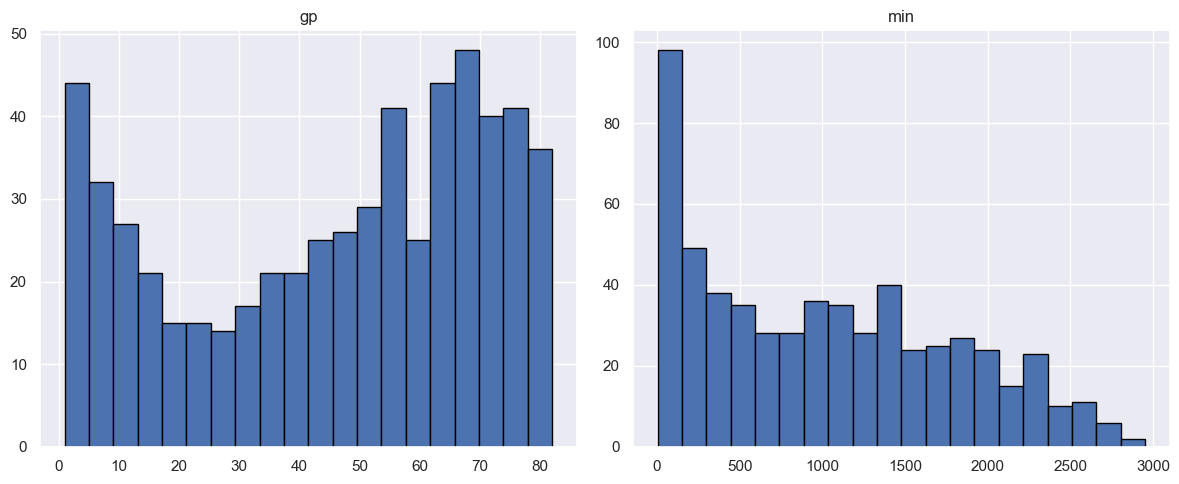

In [78]:
df[['gp', 'min']].hist(bins=20, figsize=(12, 5), edgecolor='black')
plt.tight_layout()
plt.show()

<Axes: xlabel='gp', ylabel='min'>

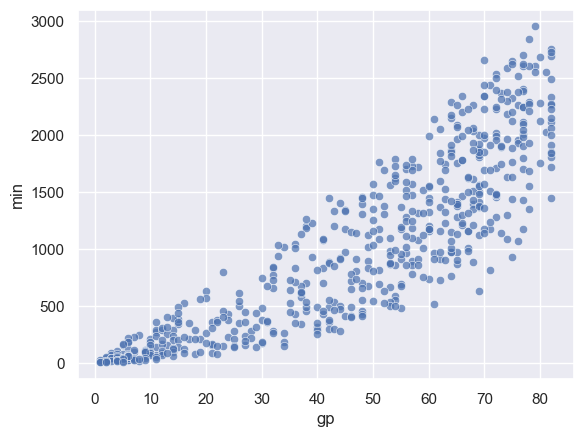

In [79]:
 sns.scatterplot(data=df, x='gp', y='min', alpha=0.7)

In [80]:
df[['min']].describe()

,min
count,582.000000
mean,1019.788660
std,771.976925
min,3.000000
25%,293.250000
50%,940.500000
75%,1609.250000
max,2953.000000


In [81]:
df['min'].median()

940.5

In [82]:
df[ df['min']<500 ][['player','team','min','gp','pts']].sort_values(by='pts', ascending=False)

,player,team,min,gp,pts
325,Ty Jerome,MEM,339,15,295
333,Obi Toppin,IND,424,24,279
339,Trae Young,WAS,384,15,269
341,D'Angelo Russell,WAS,495,26,264
351,Moritz Wagner,ORL,427,36,247
...,...,...,...,...,...
577,Jahmyl Telfort,LAC,32,8,1
578,Chucky Hepburn,TOR,13,2,0
579,Darius Brown,CLE,3,1,0
580,Noa Essengue,CHI,6,2,0


In [83]:
# Obi Toppin, Ty Jerome, and Trae Young had injuries and played very limited minutes
# D'Angelo Russell was traded to the Washington Wizards and didn't play any games once traded
# Based on the charts and summary statistics, 500 minutes seems like a reasonable cutoff to include players. This would eliminate 203 players (35%) of the dataset.
# This may be a parameter to adjust if my model results are not satisfactory.

In [84]:
df = df[ df['min']>=500 ]

In [85]:
# save the data to a new csv file
filepath = (f"../Data/nba-2-eda.csv")
df.to_csv(filepath, index=False)

# Summary

<br> - Loaded data from Step 1
<br> - Explored each of the numerical fields using ECDFs
<br> - Plotted each of the numerical fields versus salary to look for linear correlation
<br> - Decided on a 500 minute cutoff for player inclusion in the salary prediction model
<br> - The next step will be Preprocessing: normalize stats per 36 minutes played, drop highly correlated or derived fields